# Transporte de $c_1 = SO_4^{2-}$ con frontera de entrada de **1.er tipo (Dirichlet)** o **3.er tipo (Robin)**

Extensión del notebook revisado `01_C1_flow_tran`. Resuelve flujo estacionario (GWF) y transporte conservativo (GWT) con **MODFLOW 6 + FloPy** en una columna 1D de $L = 30$ m y permite **alternar la condición de frontera en $x = 0$** con un interruptor:

```python
inlet_bc = "robin"        # 3.er tipo: flujo total de masa = Q·c_in   (WEL + SSM)
inlet_bc = "dirichlet"    # 1.er tipo: concentración fija c = c_in    (WEL + SSM + CNC)
```

El notebook ejecuta tres escenarios con **ambas** condiciones y compara contra soluciones analíticas:

| Escenario | Condición inicial | Entrada $c_{in}(t)$ | Para qué sirve |
|---|---|---|---|
| `original` | fondo + pulso de 200 en $11<x<12$ | $c_{in} = c_{bg}$ | Problema de la página: la frontera casi no se nota |
| `escalon` | $c = 0$ | 1 durante 40 d | La frontera domina: se ve la diferencia entre tipos |
| `pulso_in` | $c = 0$ | 1 durante 10 d y luego 0 | $c_{in}$ variable por periodos de esfuerzo |

Un anexo cuantifica cómo crece la diferencia con la dispersividad $\alpha_L$.

## 1. Formulación matemática

### 1.1 Ecuación y condiciones

$$\theta\frac{\partial c}{\partial t} = -q_x\frac{\partial c}{\partial x} + \frac{\partial}{\partial x}\left(\theta D_{xx}\frac{\partial c}{\partial x}\right),\qquad D_{xx} = \alpha_L\,|v| + D^*,\quad v = q_x/\theta$$

El flujo total de masa por unidad de área es $J = q_x c - \theta D_{xx}\,\partial_x c$. En $x = 0$:

| Tipo | Condición | Se especifica | Implementación en MF6 |
|---|---|---|---|
| 1.º Dirichlet | $c(0,t) = c_{in}(t)$ | la concentración | `CNC` en la celda 1 |
| 3.º Robin (Danckwerts) | $q_x c - \theta D_{xx}\,\partial_x c\big\vert_0 = q_x\,c_{in}(t)$ | el **flujo total** | `WEL` + `SSM` (sin `CNC`) |

Dividiendo entre $q_x$, el Robin queda como
$$c(0,t) - \frac{D_{xx}}{v}\,\frac{\partial c}{\partial x}\bigg\vert_{0} = c_{in}(t),\qquad \frac{D_{xx}}{v} = \alpha_L + \frac{D^*}{v}$$
En $x = L$: $\partial_x c = 0$ (salida advectiva, sin flujo dispersivo).

**Interpretación.** Con Robin la concentración justo dentro de la columna es $c(0^+) = c_{in} + \alpha_L\,\partial_x c$; en un frente que avanza $\partial_x c<0$, de modo que $c(0^+) < c_{in}$ (salto de concentración en la entrada). Con Dirichlet se fuerza $c(0^+) = c_{in}$, lo que **inyecta masa adicional** por dispersión: $\Delta M \approx \theta\,c_{in}\,D_{xx}/v$ por unidad de área. El Robin conserva exactamente la masa que entra con el agua, $M(t) = Q\int_0^t c_{in}\,dt$.

### 1.2 Forma discreta (celda 1)

$$\theta V\frac{dc_1}{dt} = \underbrace{Q\,c_{in}}_{\text{SSM}} - Q\,c^{\text{cara}}_{1\to 2} + \frac{\theta D A}{\Delta x}(c_2 - c_1)$$

No hay término dispersivo en la cara izquierda. Un `CNC` en la celda 1 reemplaza esta ecuación por $c_1 = c_{in}$ (fijado en el **centro** de la celda, $x = \Delta x/2$), y MF6 ignora entonces la fuente del pozo en esa celda.

### 1.3 Soluciones analíticas (medio semi-infinito, $c(x,0)=0$, escalón $c_0$)

$$\text{3.er tipo:}\quad \frac{c}{c_0} = \tfrac12\,\mathrm{erfc}\!\left(\tfrac{x-vt}{2\sqrt{Dt}}\right) + \sqrt{\tfrac{v^2 t}{\pi D}}\,e^{-\frac{(x-vt)^2}{4Dt}} - \tfrac12\left(1+\tfrac{vx}{D}+\tfrac{v^2 t}{D}\right)e^{vx/D}\,\mathrm{erfc}\!\left(\tfrac{x+vt}{2\sqrt{Dt}}\right)$$
$$\text{1.er tipo:}\quad \frac{c}{c_0} = \tfrac12\left[\mathrm{erfc}\!\left(\tfrac{x-vt}{2\sqrt{Dt}}\right) + e^{vx/D}\,\mathrm{erfc}\!\left(\tfrac{x+vt}{2\sqrt{Dt}}\right)\right]$$

Para $c_{in}(t)$ constante por tramos, el problema es lineal y se resuelve por **superposición** de escalones desplazados. Para el pulso inicial interno (escenario `original`) se usa la gaussiana de medio infinito, válida lejos de ambas fronteras.

## 2. Bibliotecas

In [1]:
import os, re, shutil
import numpy as np
import matplotlib.pyplot as plt
import flopy
from scipy.special import erfc, erfcx

MF6_EXE = os.environ.get("MF6EXE") or shutil.which("mf6") or "/Users/luiggi/GitSites/00_NEAT/RTWMA/bin/macosarm/mf6"
print("FloPy :", flopy.__version__, "| mf6 :", MF6_EXE)
plt.rcParams.update({"mathtext.fontset": "cm", "font.family": "serif", "figure.dpi": 110})

/var/folders/fj/ptqnynxd0jx8rkcv03q2__c00000gn/T/ipykernel_48005/1195335327.py:5: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.special import erfc, erfcx


FloPy : 3.11.0 | mf6 : /Users/luiggi/GitSites/00_NEAT/RTWMA/bin/macosarm/mf6


## 3. Parámetros

In [2]:
# ---------------- Espacio ----------------
L = 30.0
nlay, nrow = 1, 1
ncol  = 240                 # dx = 0.125 m: resuelve la capa de entrada (alpha_L = 0.5 m)
delc, top, botm = 1.0, 1.0, 0.0
thick = top - botm

# ---------------- Tiempo ----------------
dt = 0.05                   # d. Cada periodo de esfuerzo se divide en pasos de este tamaño

# ---------------- Física ----------------
K, qx, theta = 1.0, 0.2, 0.5
alh      = 0.5              # dispersividad longitudinal (m)
h_out    = 1.0              # carga fija en x = L (m)
c_bg     = 1.0000329
c_pulse  = 200.0
x_pulse  = (11.0, 12.0)

# ---------------- Derivados ----------------
delr   = L / ncol
Q_well = qx * delc * thick          # m3/d
v      = qx / theta                 # m/d
D_eff  = alh * v                    # m2/d  (= 0.2)
print(f"Q = {Q_well} m3/d | v = {v} m/d | D = {D_eff} m2/d | D/v = {D_eff/v} m")
print(f"dx = {delr:.4f} m | dt = {dt} d | Courant = {v*dt/delr:.3f} | Peclet de malla = {delr/alh:.2f}")
print(f"Dispersión numérica (Euler implícito) v²dt/2 = {v**2*dt/2:.4f} m2/d ({100*v**2*dt/2/D_eff:.1f} % de D)")

Q = 0.2 m3/d | v = 0.4 m/d | D = 0.2 m2/d | D/v = 0.5 m
dx = 0.1250 m | dt = 0.05 d | Courant = 0.160 | Peclet de malla = 0.25
Dispersión numérica (Euler implícito) v²dt/2 = 0.0040 m2/d (2.0 % de D)


## 4. Funciones de construcción (con el interruptor)

- `build_flow` recibe la lista de periodos `[(duración, c_in), ...]`. **La concentración de entrada vive en el auxiliar `CONCENTRATION` del `WEL`**, y `SSM` la lee de `flow.bud`; por eso $c_{in}(t)$ debe definirse en los periodos de esfuerzo del *flujo* y el transporte usa los mismos periodos.
- `build_transport(..., inlet_bc=...)` es donde actúa el interruptor.

In [3]:
def build_flow(ws, ncol, periods):
    "GWF estacionario. periods = [(duración_d, c_in), ...]; un paso de flujo por periodo."
    nper = len(periods)
    sim = flopy.mf6.MFSimulation(sim_name="flow", sim_ws=ws, exe_name=MF6_EXE)
    flopy.mf6.ModflowTdis(sim, time_units="days", nper=nper,
                          perioddata=[(d, 1, 1.0) for d, _ in periods])
    flopy.mf6.ModflowIms(sim)
    gwf = flopy.mf6.ModflowGwf(sim, modelname="flow", save_flows=True)
    flopy.mf6.ModflowGwfdis(gwf, length_units="METERS", nlay=nlay, nrow=nrow, ncol=ncol,
                            delr=L/ncol, delc=delc, top=top, botm=botm)
    flopy.mf6.ModflowGwfnpf(gwf, k=K, icelltype=0, save_specific_discharge=True, save_saturation=True)
    flopy.mf6.ModflowGwfic(gwf, strt=h_out)
    flopy.mf6.ModflowGwfsto(gwf, steady_state={i: True for i in range(nper)})
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data=[[(0, 0, ncol-1), h_out]], pname="CHD-1")
    # WEL: inyección en x = 0. El auxiliar CONCENTRATION es c_in(t) para el transporte.
    flopy.mf6.ModflowGwfwel(gwf, auxiliary=["CONCENTRATION"], pname="WEL-1",
                            stress_period_data={i: [[(0, 0, 0), Q_well, c]] for i, (_, c) in enumerate(periods)})
    flopy.mf6.ModflowGwfoc(gwf, head_filerecord="flow.hds", budget_filerecord="flow.bud",
                           saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])
    return sim, gwf


def build_transport(ws, ncol, dt, periods, flow_ws, c_ini, pulse=None, inlet_bc="robin", alh_=None):
    '''GWT. inlet_bc = "robin"     -> 3.er tipo: solo WEL + SSM (flujo total Q*c_in)
                        "dirichlet" -> 1.er tipo: WEL + SSM + CNC (c fija en la celda 1)'''
    if inlet_bc not in ("robin", "dirichlet"):
        raise ValueError("inlet_bc debe ser 'robin' o 'dirichlet'")
    alh_ = alh if alh_ is None else alh_
    nper = len(periods)
    xc = (np.arange(ncol) + 0.5) * (L / ncol)
    sim = flopy.mf6.MFSimulation(sim_name="transport", sim_ws=ws, exe_name=MF6_EXE)
    flopy.mf6.ModflowTdis(sim, time_units="days", nper=nper,
                          perioddata=[(d, int(round(d/dt)), 1.0) for d, _ in periods])
    flopy.mf6.ModflowIms(sim, complexity="SIMPLE", linear_acceleration="BICGSTAB",
                         outer_dvclose=1e-9, inner_dvclose=1e-9)
    gwt = flopy.mf6.ModflowGwt(sim, modelname="transport", save_flows=True)
    flopy.mf6.ModflowGwtdis(gwt, length_units="METERS", nlay=nlay, nrow=nrow, ncol=ncol,
                            delr=L/ncol, delc=delc, top=top, botm=botm)
    c0 = np.full((nlay, nrow, ncol), float(c_ini))
    if pulse is not None:
        c0[0, 0, (xc > pulse[0]) & (xc < pulse[1])] = pulse[2]
    flopy.mf6.ModflowGwtic(gwt, strt=c0)
    flopy.mf6.ModflowGwtadv(gwt, scheme="TVD")
    flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=alh_, ath1=alh_)
    flopy.mf6.ModflowGwtmst(gwt, porosity=theta)
    flopy.mf6.ModflowGwtfmi(gwt, packagedata=[("GWFHEAD",   f"{os.path.relpath(flow_ws, ws)}/flow.hds", None),
                                              ("GWFBUDGET", f"{os.path.relpath(flow_ws, ws)}/flow.bud", None)])
    # SSM: el agua del pozo entra con la concentración auxiliar de WEL-1
    flopy.mf6.ModflowGwtssm(gwt, sources=[("WEL-1", "AUX", "CONCENTRATION")])

    # ===================== INTERRUPTOR =====================
    if inlet_bc == "dirichlet":
        # 1.er tipo: c = c_in(t) en el centro de la celda 1. MF6 ignora entonces la fuente del pozo ahí.
        flopy.mf6.ModflowGwtcnc(gwt, pname="CNC-1",
                                stress_period_data={i: [[(0, 0, 0), c]] for i, (_, c) in enumerate(periods)})
    # 3.er tipo (robin): no se agrega nada. WEL-1 + SSM imponen J(0,t) = Q*c_in(t).
    # ========================================================

    flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord="transport.ucn", budget_filerecord="transport.cbc",
                           saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")])
    return sim, gwt


def run(sim):
    sim.write_simulation(silent=True)
    ok, _ = sim.run_simulation(silent=True)
    assert ok, "La simulación no terminó correctamente; revisa mfsim.lst"


def max_discrepancy(lst_file):
    txt = open(lst_file).read()
    vals = [abs(float(m)) for m in re.findall(r"PERCENT DISCREPANCY\s*=\s*(-?[\d.]+)", txt)]
    return max(vals) if vals else np.nan


def simulate(root, periods, c_ini, pulse=None, alh_=None, bcs=("robin", "dirichlet"), ncol=ncol):
    "Corre el flujo una vez y el transporte con cada condición de entrada."
    flow_ws = f"{root}/gwf"
    sim_f, gwf = build_flow(flow_ws, ncol, periods); run(sim_f)
    out = {"gwf": gwf, "x": gwf.modelgrid.xcellcenters[0], "flow_ws": flow_ws,
           "disc_flow": max_discrepancy(f"{flow_ws}/flow.lst")}
    for bc in bcs:
        ws = f"{root}/gwt_{bc}"
        sim_t, gwt = build_transport(ws, ncol, dt, periods, flow_ws, c_ini, pulse, bc, alh_); run(sim_t)
        oc = gwt.output.concentration()
        out[bc] = dict(t=np.array(oc.get_times()), c=oc.get_alldata()[:, 0, 0, :],
                       disc=max_discrepancy(f"{ws}/transport.lst"))
    return out

## 5. Soluciones analíticas

In [4]:
def A3(x, t, D=D_eff, v=v):
    "3.er tipo (Robin), escalón unitario, c_ini = 0, medio semi-infinito."
    x = np.asarray(x, float)
    if t <= 0: return np.zeros_like(x)
    s = 2*np.sqrt(D*t)
    return (0.5*erfc((x - v*t)/s) + np.sqrt(v*v*t/(np.pi*D))*np.exp(-(x - v*t)**2/(4*D*t))
            - 0.5*(1 + v*x/D + v*v*t/D)*np.exp(v*x/D - ((x + v*t)/s)**2)*erfcx((x + v*t)/s))

def A1(x, t, D=D_eff, v=v):
    "1.er tipo (Dirichlet), escalón unitario, c_ini = 0 (Ogata-Banks)."
    x = np.asarray(x, float)
    if t <= 0: return np.zeros_like(x)
    s = 2*np.sqrt(D*t)
    return 0.5*(erfc((x - v*t)/s) + np.exp(v*x/D - ((x + v*t)/s)**2)*erfcx((x + v*t)/s))

def c_step_series(x, t, periods, A):
    "c_in constante por tramos, c_ini = 0: superposición de escalones desplazados."
    c = np.zeros_like(np.asarray(x, float)); t_i, prev = 0.0, 0.0
    for dur, cin in periods:
        c = c + (cin - prev) * A(x, t - t_i)
        t_i += dur; prev = cin
    return c

def c_gauss(x, t, D=D_eff, v=v, x0=0.5*sum(x_pulse), cb=c_bg,
            M=(c_pulse - c_bg)*(x_pulse[1] - x_pulse[0])):
    "Pulso interno en medio infinito (válido lejos de las fronteras)."
    return cb + M/np.sqrt(4*np.pi*D*t)*np.exp(-(x - x0 - v*t)**2/(4*D*t))

def rel_L1(c, a, m):
    "Error relativo L1 (%) sobre las celdas seleccionadas por la máscara m."
    return 100*np.abs(c[m] - a[m]).sum()/np.abs(a[m]).sum()

mass = lambda c: theta*delc*thick*(L/len(c))*np.sum(c)     # masa de soluto en el dominio

## 6. Ejecución de los escenarios

Cada escenario corre **un** flujo y **dos** transportes (`robin` y `dirichlet`). Los directorios son `io_mf6/c1_bc/<escenario>/{gwf, gwt_robin, gwt_dirichlet}`.

In [5]:
scenarios = {
    "original": dict(titulo="Problema original", c_ini=c_bg, pulse=(*x_pulse, c_pulse), periods=[(40.0, c_bg)]),
    "escalon":  dict(titulo="Escalón de entrada", c_ini=0.0, pulse=None, periods=[(40.0, 1.0)]),
    "pulso_in": dict(titulo="Pulso de entrada",   c_ini=0.0, pulse=None, periods=[(10.0, 1.0), (30.0, 0.0)]),
}
R = {}
for name, s in scenarios.items():
    R[name] = simulate(f"io_mf6/c1_bc/{name}", s["periods"], s["c_ini"], s["pulse"])
    print(f"{name:9s} | pasos: {len(R[name]['robin']['t']):4d} | discrepancia máx. flujo = {R[name]['disc_flow']:.4f} % | "
          f"masa: Robin {R[name]['robin']['disc']:.4f} %, Dirichlet {R[name]['dirichlet']['disc']:.4f} %")
x = R["original"]["x"]

original  | pasos:  800 | discrepancia máx. flujo = 0.0000 % | masa: Robin 0.0000 %, Dirichlet 0.0000 %
escalon   | pasos:  800 | discrepancia máx. flujo = 0.0000 % | masa: Robin 0.0000 %, Dirichlet 0.0000 %
pulso_in  | pasos:  800 | discrepancia máx. flujo = 0.0000 % | masa: Robin 0.0000 %, Dirichlet 0.0000 %


escalon   | pasos:  800 | discrepancia máx. flujo = 0.0000 % | masa: Robin 0.0000 %, Dirichlet 0.0000 %


pulso_in  | pasos:  800 | discrepancia máx. flujo = 0.0000 % | masa: Robin 0.0000 %, Dirichlet 0.0000 %


### 6.1 Verificación del flujo (común a todos los escenarios)

max |h - h_analítica| = 2.31e-14 m | qx = 0.200000 … 0.200000 m/d


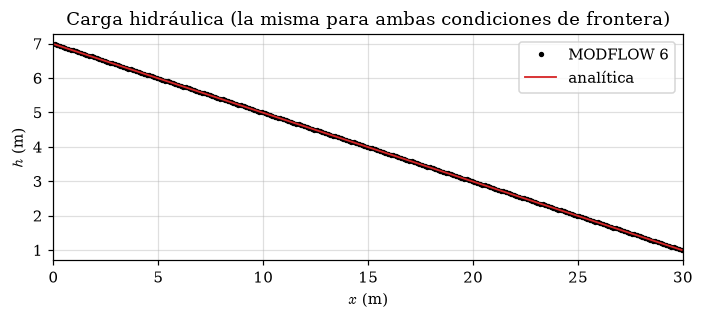

In [6]:
gwf = R["original"]["gwf"]
head = gwf.output.head().get_data()[0, 0, :]
spdis = gwf.output.budget().get_data(text="DATA-SPDIS")[0]
qx_num = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)[0]
# El CHD fija h en el CENTRO de la última celda (x = L - dx/2)
h_exact = h_out + (qx/K)*(x[-1] - x)
print(f"max |h - h_analítica| = {np.abs(head - h_exact).max():.2e} m | qx = {qx_num.min():.6f} … {qx_num.max():.6f} m/d")
assert np.abs(head - h_exact).max() < 1e-8 and np.allclose(qx_num, qx)

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(x, head, "o", ms=2.5, c="k", label="MODFLOW 6"); ax.plot(x, h_exact, c="C3", lw=1.2, label="analítica")
ax.set_xlabel("$x$ (m)"); ax.set_ylabel("$h$ (m)"); ax.grid(alpha=.4); ax.legend(); ax.set_xlim(0, L)
ax.set_title("Carga hidráulica (la misma para ambas condiciones de frontera)")
plt.tight_layout(); plt.show()

## 7. Escenario `original`: pulso interno con $c_{in} = c_{bg}$

Aquí la frontera de entrada prácticamente no influye, porque el soluto de la entrada es igual al fondo y el pulso está a 11 m. Es la razón por la que, en el problema de la página, la diferencia entre `CNC` y Robin pasaba desapercibida.

t = 40 d | pico Robin = 20.6161 | pico Dirichlet = 20.6161 | pico analítico = 20.8450
max |c_Robin - c_Dirichlet| = 3.48e-09  (sobre un pico de 20.6)
Error L1 vs gaussiana (x ≤ 27): Robin 0.80 % | Dirichlet 0.80 %


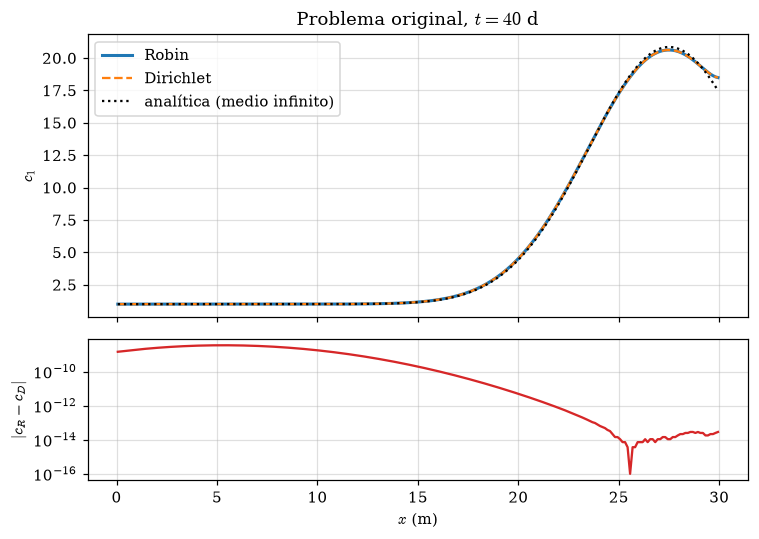

In [7]:
r = R["original"]; tt = r["robin"]["t"]; k = -1
cR, cD = r["robin"]["c"][k], r["dirichlet"]["c"][k]
m = x <= 27
ca = c_gauss(x, tt[k])
print(f"t = {tt[k]:.0f} d | pico Robin = {cR.max():.4f} | pico Dirichlet = {cD.max():.4f} | pico analítico = {ca.max():.4f}")
print(f"max |c_Robin - c_Dirichlet| = {np.abs(cR - cD).max():.2e}  (sobre un pico de {cR.max():.1f})")
print(f"Error L1 vs gaussiana (x ≤ 27): Robin {rel_L1(cR, ca, m):.2f} % | Dirichlet {rel_L1(cD, ca, m):.2f} %")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=[2, 1])
a1.plot(x, cR, c="C0", lw=2, label="Robin"); a1.plot(x, cD, "--", c="C1", lw=1.5, label="Dirichlet")
a1.plot(x, ca, ":", c="k", label="analítica (medio infinito)")
a1.set_ylabel("$c_1$"); a1.legend(); a1.grid(alpha=.4); a1.set_title("Problema original, $t = 40$ d")
a2.semilogy(x, np.abs(cR - cD) + 1e-16, c="C3"); a2.set_ylabel("$|c_R - c_D|$"); a2.set_xlabel("$x$ (m)"); a2.grid(alpha=.4, which="both")
plt.tight_layout(); plt.show()

## 8. Escenario `escalon`: $c(x,0) = 0$ y $c_{in} = 1$

Aquí la frontera sí manda. Cada simulación debe parecerse a **su** analítica y alejarse de la otra.

In [8]:
r = R["escalon"]; per = scenarios["escalon"]["periods"]; tR, tD = r["robin"]["t"], r["dirichlet"]["t"]
m = x <= 25
print(f"{'t (d)':>6} | {'Robin vs 3.er tipo':>19} {'Dirich. vs 1.er tipo':>21} | {'Robin vs 1.er':>14} {'Dirich. vs 3.er':>16}   (error L1 %, x ≤ 25 m)")
for tt in [2, 5, 10, 20, 40]:
    k = np.argmin(abs(tR - tt))
    a3, a1 = c_step_series(x, tR[k], per, A3), c_step_series(x, tR[k], per, A1)
    print(f"{tt:6d} | {rel_L1(r['robin']['c'][k], a3, m):19.2f} {rel_L1(r['dirichlet']['c'][k], a1, m):21.2f} | "
          f"{rel_L1(r['robin']['c'][k], a1, m):14.2f} {rel_L1(r['dirichlet']['c'][k], a3, m):16.2f}")

 t (d) |  Robin vs 3.er tipo  Dirich. vs 1.er tipo |  Robin vs 1.er  Dirich. vs 3.er   (error L1 %, x ≤ 25 m)
     2 |                1.35                  6.17 |          33.61            59.98
     5 |                0.70                  3.05 |          19.08            27.36
    10 |                0.45                  1.69 |          11.00            14.26
    20 |                0.30                  0.90 |           5.88             7.20
    40 |                0.19                  0.44 |           3.01             3.55


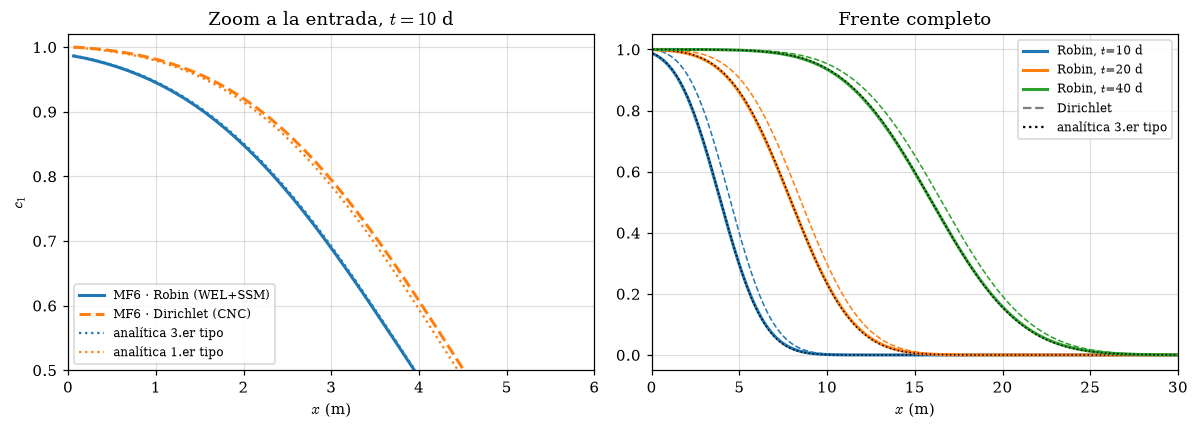

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
t0 = 10; k = np.argmin(abs(tR - t0))
a1.plot(x, r["robin"]["c"][k], c="C0", lw=2, label="MF6 · Robin (WEL+SSM)")
a1.plot(x, r["dirichlet"]["c"][k], "--", c="C1", lw=2, label="MF6 · Dirichlet (CNC)")
a1.plot(x, A3(x, t0), ":", c="C0", lw=1.5, label="analítica 3.er tipo")
a1.plot(x, A1(x, t0), ":", c="C1", lw=1.5, label="analítica 1.er tipo")
a1.set_xlim(0, 6); a1.set_ylim(0.5, 1.02); a1.set_xlabel("$x$ (m)"); a1.set_ylabel("$c_1$")
a1.set_title(f"Zoom a la entrada, $t = {t0}$ d"); a1.grid(alpha=.4); a1.legend(fontsize=8, loc="lower left")

for i, tt in enumerate([10, 20, 40]):
    k = np.argmin(abs(tR - tt))
    a2.plot(x, r["robin"]["c"][k], c=f"C{i}", lw=2, label=f"Robin, $t$={tt} d")
    a2.plot(x, r["dirichlet"]["c"][k], "--", c=f"C{i}", lw=1)
    a2.plot(x, A3(x, tt), ":", c="k", lw=1)
a2.plot([], [], "--", c="gray", label="Dirichlet"); a2.plot([], [], ":", c="k", label="analítica 3.er tipo")
a2.set_xlim(0, L); a2.set_xlabel("$x$ (m)"); a2.grid(alpha=.4); a2.legend(fontsize=8); a2.set_title("Frente completo")
plt.tight_layout(); plt.show()

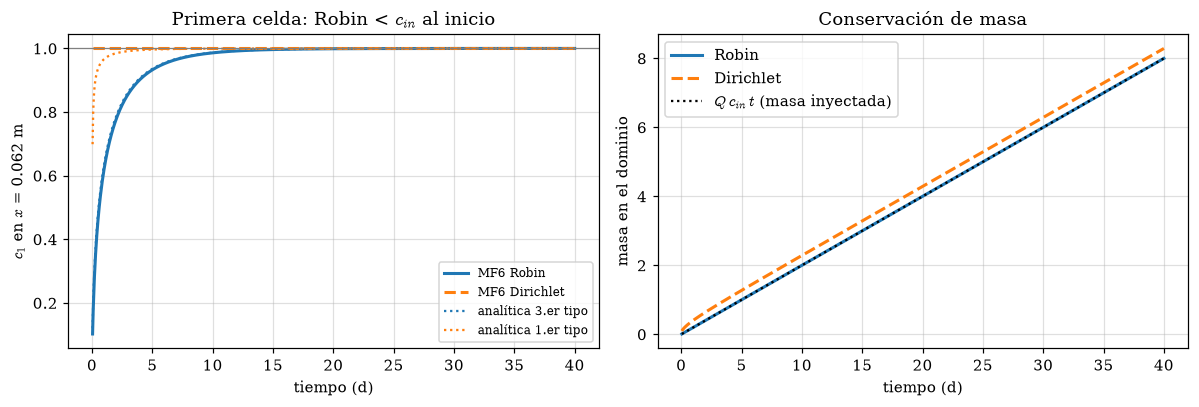

t = 10 d | inyectado Q·c_in·t = 2.0000 | Robin = 2.0000 | Dirichlet = 2.2851 (exceso 0.2851; θ·c_in·(D/v + dx/2) = 0.2812)
Primera celda a t=10 d: Robin = 0.9862 (analítica 0.9870) | Dirichlet = 1.0000


In [10]:
# Concentración en la primera celda (x = dx/2) y masa en el dominio
j = 0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(tR, r["robin"]["c"][:, j], c="C0", lw=2, label="MF6 Robin"); a1.plot(tD, r["dirichlet"]["c"][:, j], "--", c="C1", lw=2, label="MF6 Dirichlet")
a1.plot(tR, [A3(x[j], t) for t in tR], ":", c="C0", label="analítica 3.er tipo"); a1.plot(tR, [A1(x[j], t) for t in tR], ":", c="C1", label="analítica 1.er tipo")
a1.axhline(1, c="gray", lw=.8); a1.set_xlabel("tiempo (d)"); a1.set_ylabel(f"$c_1$ en $x$ = {x[j]:.3f} m"); a1.grid(alpha=.4); a1.legend(fontsize=8)
a1.set_title("Primera celda: Robin < $c_{in}$ al inicio")

mR = np.array([mass(c) for c in r["robin"]["c"]]); mD = np.array([mass(c) for c in r["dirichlet"]["c"]])
a2.plot(tR, mR, c="C0", lw=2, label="Robin"); a2.plot(tD, mD, "--", c="C1", lw=2, label="Dirichlet")
a2.plot(tR, Q_well*1.0*tR, ":", c="k", label="$Q\\,c_{in}\\,t$ (masa inyectada)")
a2.set_xlabel("tiempo (d)"); a2.set_ylabel("masa en el dominio"); a2.grid(alpha=.4); a2.legend(); a2.set_title("Conservación de masa")
plt.tight_layout(); plt.show()

k10 = np.argmin(abs(tR - 10))
print(f"t = 10 d | inyectado Q·c_in·t = {Q_well*10:.4f} | Robin = {mR[k10]:.4f} | Dirichlet = {mD[k10]:.4f} "
      f"(exceso {mD[k10]-mR[k10]:.4f}; θ·c_in·(D/v + dx/2) = {theta*(D_eff/v + delr/2):.4f})")
print(f"Primera celda a t=10 d: Robin = {r['robin']['c'][k10, 0]:.4f} (analítica {A3(x[0], 10):.4f}) | Dirichlet = {r['dirichlet']['c'][k10, 0]:.4f}")

## 9. Escenario `pulso_in`: $c_{in}(t)$ variable por periodos de esfuerzo

$c_{in}=1$ durante 10 d y luego 0. El efecto de la frontera de entrada se ve en la forma de la cola trasera del pulso y en la masa retenida.

 t (d) |  Robin vs 3.er tipo  Dirich. vs 1.er tipo | masa Robin  masa Dirichlet   (inyectada total = 2.00)
     5 |                0.70                  3.05 |     1.0000        1.2735
    10 |                0.45                  1.69 |     2.0000        2.2851
    15 |                0.79                  2.86 |     2.0000        2.0138
    25 |                0.89                  2.21 |     2.0000        2.0007
    40 |                0.88                  1.70 |     1.9999        1.9998


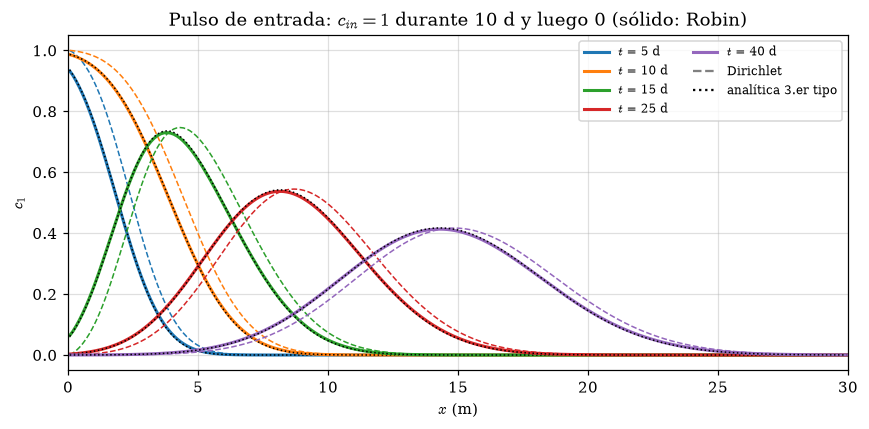

In [11]:
r = R["pulso_in"]; per = scenarios["pulso_in"]["periods"]; tR = r["robin"]["t"]; m = x <= 25
print(f"{'t (d)':>6} | {'Robin vs 3.er tipo':>19} {'Dirich. vs 1.er tipo':>21} | masa Robin  masa Dirichlet   (inyectada total = {Q_well*10:.2f})")
for tt in [5, 10, 15, 25, 40]:
    k = np.argmin(abs(tR - tt))
    a3, a1 = c_step_series(x, tR[k], per, A3), c_step_series(x, tR[k], per, A1)
    print(f"{tt:6d} | {rel_L1(r['robin']['c'][k], a3, m):19.2f} {rel_L1(r['dirichlet']['c'][k], a1, m):21.2f} | "
          f"{mass(r['robin']['c'][k]):10.4f} {mass(r['dirichlet']['c'][k]):13.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
for i, tt in enumerate([5, 10, 15, 25, 40]):
    k = np.argmin(abs(tR - tt))
    ax.plot(x, r["robin"]["c"][k], c=f"C{i}", lw=2, label=f"$t$ = {tt} d")
    ax.plot(x, r["dirichlet"]["c"][k], "--", c=f"C{i}", lw=1)
    ax.plot(x, c_step_series(x, tR[k], per, A3), ":", c="k", lw=1)
ax.plot([], [], "--", c="gray", label="Dirichlet"); ax.plot([], [], ":", c="k", label="analítica 3.er tipo")
ax.set_xlim(0, L); ax.set_xlabel("$x$ (m)"); ax.set_ylabel("$c_1$"); ax.grid(alpha=.4); ax.legend(fontsize=8, ncol=2)
ax.set_title("Pulso de entrada: $c_{in}=1$ durante 10 d y luego 0 (sólido: Robin)")
plt.tight_layout(); plt.show()

## 10. Anexo: la diferencia crece con $\alpha_L$

La masa adicional que inyecta el Dirichlet respecto al Robin es, **en el límite asintótico**, $\Delta M \approx \theta\,c_{in}\,(D/v + \Delta x/2)$, donde $D/v = \alpha_L$ y el término $\Delta x/2$ aparece porque `CNC` fija $c$ en el centro de la celda y no en la cara.

La aproximación exige **dos condiciones**: $t \gg \alpha_L/v$ (tiempo característico de la capa de entrada) y $\alpha_L \gtrsim \Delta x$ (que la capa esté resuelta por la malla). Por eso se incluye la columna $\alpha_L/v$: se espera que la fórmula falle para $\alpha_L$ muy pequeño (dominado por la dispersión numérica) y para $\alpha_L$ grande (a $t = 10$ d aún no se alcanza el régimen asintótico).

alpha_L (m)  alpha_L/v (d)  ΔM medido  θ(αL+dx/2)  error %  c1(Robin)  c1(Dirich.)   (t = 10 d, primera celda)
       0.10           0.25     0.1009      0.0813     24.2     1.0000       1.0000
       0.25           0.62     0.1679      0.1562      7.5     0.9988       1.0000
       0.50           1.25     0.2851      0.2812      1.4     0.9862       1.0000
       1.00           2.50     0.5062      0.5312     -4.7     0.9385       1.0000
       2.00           5.00     0.8818      1.0312    -14.5     0.8437       1.0000


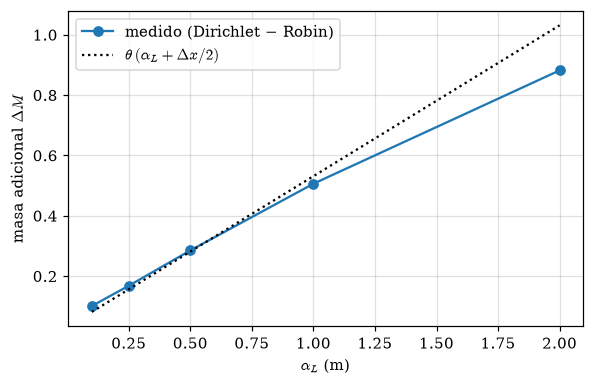

In [12]:
rows = []
for a in [0.1, 0.25, 0.5, 1.0, 2.0]:
    rr = simulate(f"io_mf6/c1_bc/sweep_{a}", scenarios["escalon"]["periods"], 0.0, alh_=a)
    t_ = rr["robin"]["t"]; k = np.argmin(abs(t_ - 10))
    dM = mass(rr["dirichlet"]["c"][k]) - mass(rr["robin"]["c"][k])
    rows.append((a, dM, theta*(a + delr/2), rr["robin"]["c"][k, 0], rr["dirichlet"]["c"][k, 0], a/v))
print(f"{'alpha_L (m)':>11} {'alpha_L/v (d)':>14} {'ΔM medido':>10} {'θ(αL+dx/2)':>11} {'error %':>8} {'c1(Robin)':>10} {'c1(Dirich.)':>12}   (t = 10 d, primera celda)")
for rw in rows: print(f"{rw[0]:11.2f} {rw[5]:14.2f} {rw[1]:10.4f} {rw[2]:11.4f} {100*(rw[1]-rw[2])/rw[2]:8.1f} {rw[3]:10.4f} {rw[4]:12.4f}")

fig, ax = plt.subplots(figsize=(5.5, 3.6))
al = np.array([rw[0] for rw in rows])
ax.plot(al, [rw[1] for rw in rows], "o-", label="medido (Dirichlet − Robin)")
ax.plot(al, [rw[2] for rw in rows], "k:", label="$\\theta\\,(\\alpha_L + \\Delta x/2)$")
ax.set_xlabel("$\\alpha_L$ (m)"); ax.set_ylabel("masa adicional $\\Delta M$"); ax.grid(alpha=.4); ax.legend()
plt.tight_layout(); plt.show()

## 11. Cómo usar el interruptor y cuál elegir

Para una corrida individual basta:

```python
periods = [(40.0, c_bg)]                      # [(duración, c_in), ...]
res = simulate("io_mf6/mi_caso", periods, c_ini=c_bg, pulse=(11., 12., 200.), bcs=("robin",))   # o ("dirichlet",)
x, t, c = res["x"], res["robin"]["t"], res["robin"]["c"]
```

| | Robin (3.er tipo) | Dirichlet (1.er tipo) |
|---|---|---|
| Se especifica | flujo total de masa $Q\,c_{in}$ | concentración en la celda 1 |
| Masa inyectada | exactamente $Q\int c_{in}\,dt$ | $Q\int c_{in}\,dt$ + aporte dispersivo extra |
| Adecuado para | entrada de agua con concentración conocida (pozo, columna, recarga) | un reservorio bien mezclado con concentración fija |
| Paquetes | `WEL` + `SSM` | `WEL` + `SSM` + `CNC` (el pozo no aporta masa en esa celda) |

**Limitaciones**

- MF6 implementa el Robin en su forma de **flujo total** (Danckwerts), con $b/a = -D/v$ fijado por el transporte. Un Robin con coeficiente de transferencia independiente, $-\theta D\,\partial_x c = h\,(c_{ext}-c)$, no está disponible directamente.
- $c_{in}(t)$ debe definirse en los periodos de esfuerzo del **flujo** (el auxiliar del `WEL` se lee de `flow.bud`).
- La capa de entrada mide $\alpha_L$; conviene $\Delta x \lesssim \alpha_L/2$ para resolverla. Con $\Delta x \gtrsim \alpha_L$ el efecto del Robin queda dentro de una sola celda y la comparación entre tipos pasa a estar dominada por la posición del `CNC` en el centro de la celda ($\Delta x/2$), no por la física de la frontera.
- La fórmula de masa adicional del anexo es asintótica; no debe usarse para $t \lesssim \alpha_L/v$.
- Las analíticas son de medio semi-infinito: sólo valen mientras el frente esté lejos de $x = L$ (por eso el error se mide en $x \le 25$ m).
- El `escalon` y el `pulso_in` usan $c(x,0)=0$ para que la frontera domine; no son el problema de la página.

## Referencias

- van Genuchten, M. Th., & Alves, W. J. (1982). *Analytical solutions of the one-dimensional convective-dispersive solute transport equation.* USDA Tech. Bull. 1661.
- Langevin, C. D., Hughes, J. D., Provost, A. M., Russcher, M. J., & Panday, S. (2023). MODFLOW as a configurable Multi-Model Hydrologic Simulator. *Ground Water*. https://doi.org/10.1111/gwat.13351